In [138]:
import numpy as np
from mqt.qecc.circuit_synthesis import CNOTCircuit, gate_optimal_verification_stabilizers
from mqt.qecc.circuit_synthesis.faults import PureFaultSet

from spiderstate.cat_at_origin import cat_at_origin
from spiderstate.optimize_parity_matrix import optimize_fault_tolerant_matrix
from spiderstate.utils import load_qecc, flatten

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [279]:
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc("15_7_3", "mqt")
t = (d - 1) // 2

row_M, final_M, col_ops = optimize_fault_tolerant_matrix(H_x, t=t, max_col_ops=10, max_basis_tries=10_000)
print(final_M, col_ops, sep="\n\n")

print(len(col_ops))

[[0 0 0 0 0 0 1 0 0 1 1 0 0 0 0]
 [0 0 0 1 0 0 1 0 0 0 0 1 1 1 1]
 [1 1 0 0 1 1 0 1 0 0 1 1 0 0 0]
 [0 0 0 1 0 0 0 1 1 0 0 0 0 0 0]]

[(9, 2), (8, 2), (2, 13), (6, 5), (3, 4), (2, 1), (1, 14)]
7


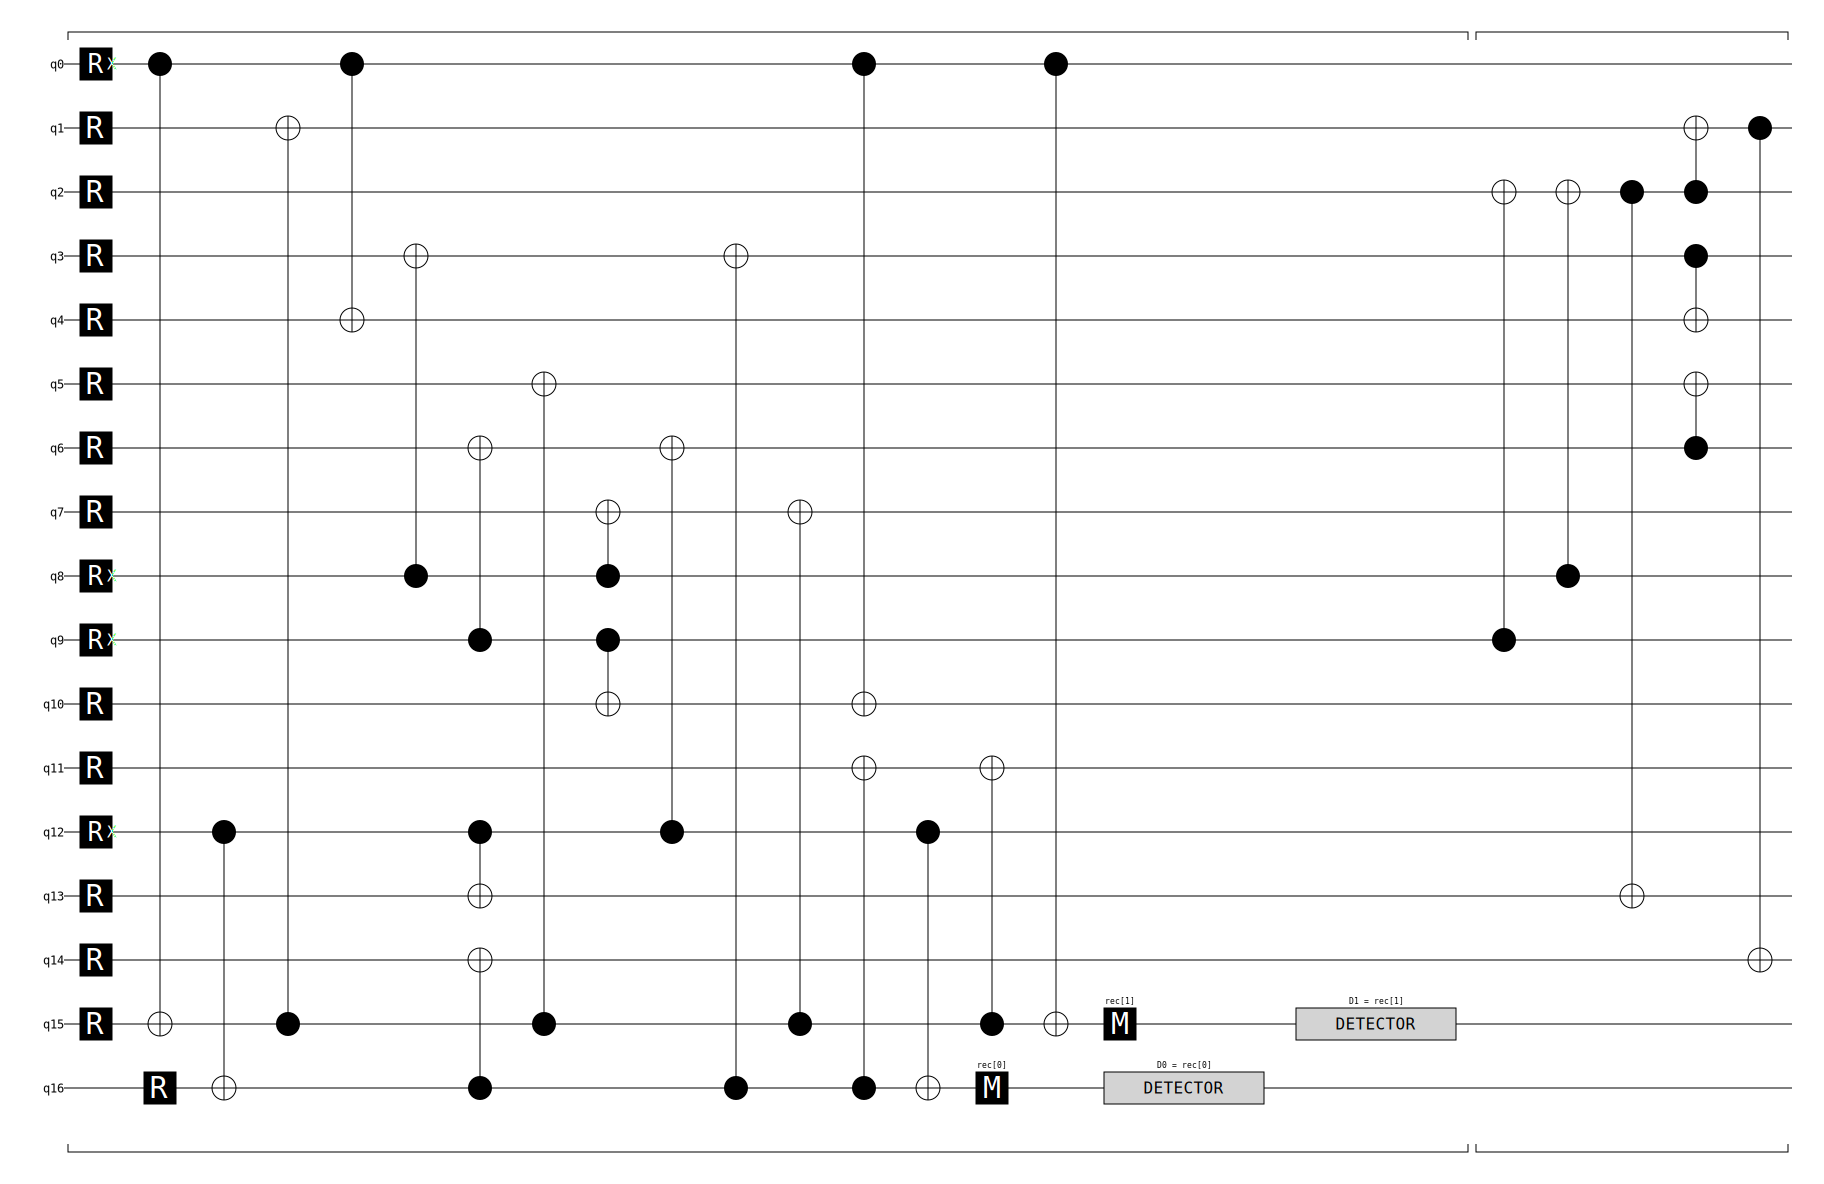

In [280]:
circ = cat_at_origin(final_M, d)
circ.append("TICK", [])
circ.append("CX", flatten(col_ops))
circ.diagram('timeline-svg')

In [281]:
circuit = circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(10)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ H_z.T % 2)

[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]


In [282]:
from mqt.qecc.circuit_synthesis.faults import product_fault_set


def compute_unitary_fault_sets(cnots: list[tuple[int, int]], num_qubits: int, max_errors: int, kind: str = "X"):
    """
    Computes a list of fault sets for a unitary CNOT circuit up to max_errors.
    Returns a list where index i contains the fault set for i+1 independent errors.
    """
    if max_errors < 1:
        raise ValueError("Cannot compute fault sets for less than 1 error.")

    # 1. Establish the Physical Baseline
    circ = CNOTCircuit()
    seen = set()
    for (c, n) in cnots:
        if c not in seen:
            seen.add(c)
            circ.initialize_qubit(c, "X")
        if n not in seen:
            seen.add(n)
            circ.initialize_qubit(n, "Z")
    for rem in set(range(num_qubits)) - seen:
        circ.initialize_qubit(rem, "Z")
    circ.add_cnots(cnots)

    # 2. Compute the Root Fault Set (1 Error)
    single_faults = PureFaultSet.from_cnot_circuit(circ, kind=kind)
    single_faults.remove_zero_rows()
    single_faults.remove_duplicates()

    fault_sets_unreduced = [single_faults.copy()]

    # 3. Iteratively Construct Higher-Weight Faults
    for i in range(1, max_errors):
        last_faults = fault_sets_unreduced[-1]

        # Take the tensor product of the (N-1) fault set with the single fault set
        next_faults = product_fault_set(last_faults, single_faults)
        next_faults.remove_zero_rows()
        next_faults.remove_duplicates()
        next_faults.remove_equivalent(H_z)

        fault_sets_unreduced.append(next_faults.copy())

    fault_set_ret = []
    for i, fault in enumerate(fault_sets_unreduced, 1):
        fault.filter_by_weight_at_least(i + 1, H_x)
        fault_set_ret.append(fault)

    return fault_set_ret

cnots = col_ops
compute_unitary_fault_sets(cnots, num_qubits=H_x.shape[1], max_errors=t, kind="X")

[PureFaultSet(num_qubits=15, faults=[[0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0], [0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1], [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]])]

In [283]:
ver_x_stabs_layers = gate_optimal_verification_stabilizers(compute_unitary_fault_sets(cnots, num_qubits=H_x.shape[1], max_errors=t, kind="X"), np.concatenate((H_z, L_z)), max_timeout=5)
print(ver_x_stabs_layers)

[[array([0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int8)]]


In [ ]:
"""
Given AtomicFaults, Stabilisers, and (MeasuredStabs if exists)


L_1 = {(f, 1) for f in AtomicFaults}

L_plus = {(f, w) for (f, w) in L_1 if f commutes with all MeasuredStabs}
L_minus = {(f, w) for (f, w) in L_1 if f anti-commutes with any MeasuredStabs}

L_2 = (
    L_plus
    | {(f, w + 1) for (f, w) in L_minus}
    | L_minus tenor L_minus
    [= {(f_a xor f_b, w_a + w_b) for (f_a, w_a) in L_minus for (f_b, w_b) in L_minus}]
)
"""
